# 07 — Final Model Comparison

In this notebook, we compare the two final sentiment-classification
approaches:

1. TF-IDF + Logistic Regression
2. Fine-tuned DistilBERT

We compare:

- Accuracy
- Precision
- Recall
- F1
- Inference cost
- Model complexity
- Strengths and limitations

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
CURRENT_DIR = Path.cwd().resolve()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

print(
    "Project root:",
    PROJECT_ROOT,
)

Project root: D:\app\ai\Sentiment Analysis Traditional ML vs Transformers


In [3]:
TRADITIONAL_METRICS_PATH = (
    PROJECT_ROOT
    / "reports"
    / "best_traditional"
    / "test_evaluation"
    / "test_metrics.csv"
)

In [4]:
traditional_metrics_df = pd.read_csv(
    TRADITIONAL_METRICS_PATH
)

traditional_metrics_df

,metric,value
0,accuracy,0.876240
1,precision_positive,0.868805
2,recall_positive,0.886320
3,f1_positive,0.877475
4,macro_f1,0.876227
5,vectorization_seconds,4.845168
6,inference_seconds,1.434534
7,test_rows,25000.000000


In [5]:
traditional_metrics = dict(
    zip(
        traditional_metrics_df[
            "metric"
        ],
        traditional_metrics_df[
            "value"
        ],
    )
)

In [6]:
traditional_metrics

{'accuracy': 0.87624,
 'precision_positive': 0.8688048933500627,
 'recall_positive': 0.88632,
 'f1_positive': 0.8774750514810709,
 'macro_f1': 0.8762274239141252,
 'vectorization_seconds': 4.845168100000592,
 'inference_seconds': 1.4345337999984622,
 'test_rows': 25000.0}

In [7]:
DISTILBERT_METRICS_PATH = (
    PROJECT_ROOT
    / "reports"
    / "distilbert"
    / "test_evaluation"
    / "test_metrics.csv"
)

distilbert_metrics_df = pd.read_csv(
    DISTILBERT_METRICS_PATH
)

distilbert_metrics_df

,metric,value
0,accuracy,0.873560
1,precision_positive,0.880842
2,recall_positive,0.864000
3,f1_positive,0.872340
4,test_loss,0.311351
5,test_seconds,39.129423
6,test_rows,25000.000000


In [8]:
distilbert_metrics = dict(
    zip(
        distilbert_metrics_df[
            "metric"
        ],
        distilbert_metrics_df[
            "value"
        ],
    )
)

In [9]:
comparison_df = pd.DataFrame(
    [
        {
            "model": (
                "TF-IDF + Logistic Regression"
            ),
            "accuracy": (
                traditional_metrics[
                    "accuracy"
                ]
            ),
            "precision": (
                traditional_metrics[
                    "precision_positive"
                ]
            ),
            "recall": (
                traditional_metrics[
                    "recall_positive"
                ]
            ),
            "f1": (
                traditional_metrics[
                    "f1_positive"
                ]
            ),
        },
        {
            "model": (
                "DistilBERT"
            ),
            "accuracy": (
                distilbert_metrics[
                    "accuracy"
                ]
            ),
            "precision": (
                distilbert_metrics[
                    "precision_positive"
                ]
            ),
            "recall": (
                distilbert_metrics[
                    "recall_positive"
                ]
            ),
            "f1": (
                distilbert_metrics[
                    "f1_positive"
                ]
            ),
        },
    ]
)

comparison_df

,model,accuracy,precision,recall,f1
0,TF-IDF + Logistic Regression,0.87624,0.868805,0.88632,0.877475
1,DistilBERT,0.87356,0.880842,0.86400,0.872340


In [10]:
best_model_row = (
    comparison_df
    .sort_values(
        by="f1",
        ascending=False,
    )
    .iloc[0]
)

print(
    "Best model:",
    best_model_row["model"],
)

print(
    "Best Test F1:",
    f"{best_model_row['f1']:.4f}",
)

Best model: TF-IDF + Logistic Regression
Best Test F1: 0.8775


In [11]:
f1_difference = (
    distilbert_metrics[
        "f1_positive"
    ]
    - traditional_metrics[
        "f1_positive"
    ]
)

accuracy_difference = (
    distilbert_metrics[
        "accuracy"
    ]
    - traditional_metrics[
        "accuracy"
    ]
)

print(
    "DistilBERT Δ F1:",
    f"{f1_difference:+.4f}",
)

print(
    "DistilBERT Δ Accuracy:",
    f"{accuracy_difference:+.4f}",
)

DistilBERT Δ F1: -0.0051
DistilBERT Δ Accuracy: -0.0027


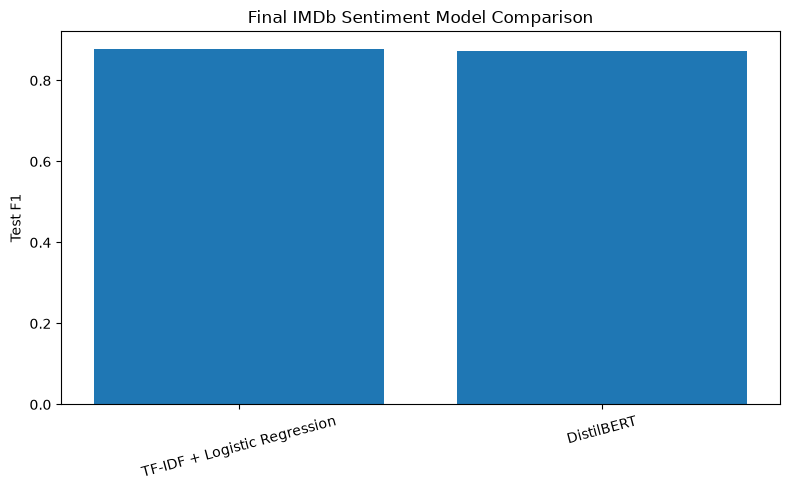

In [12]:
plt.figure(
    figsize=(8, 5)
)

plt.bar(
    comparison_df["model"],
    comparison_df["f1"],
)

plt.ylabel(
    "Test F1"
)

plt.title(
    "Final IMDb Sentiment Model Comparison"
)

plt.xticks(
    rotation=15
)

plt.tight_layout()

plt.show()

In [21]:
model_tradeoff_df = pd.DataFrame(
    [
        {
            "model": "TF-IDF + Logistic Regression",
            "representation": (
                "Sparse statistical features"
            ),
            "context_understanding": "Limited",
            "training_cost": "Low",
            "inference_cost": "Low",
            "interpretability": "High",
            "deployment_complexity": "Low",
        },
        {
            "model": "DistilBERT",
            "representation": (
                "Contextual token representations"
            ),
            "context_understanding": "High",
            "training_cost": "High",
            "inference_cost": "High",
            "interpretability": "Lower",
            "deployment_complexity": "Higher",
        },
    ]
)

model_tradeoff_df

,model,representation,context_understanding,training_cost,inference_cost,interpretability,deployment_complexity
0,TF-IDF + Logistic Regression,Sparse statistical features,Limited,Low,Low,High,Low
1,DistilBERT,Contextual token representations,High,High,High,Lower,Higher
